In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
df = pd.read_csv('HRDataset.csv')

In [48]:
df.head()

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,PayRate,...,Department,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30
0,"Brown, Mia",1.103024e+09,1.0,1.0,0.0,1.0,1.0,3.0,1.0,28.50,...,Admin Offices,Brandon R. LeBlanc,1.0,Diversity Job Fair,Fully Meets,2.04,2.0,6.0,1/15/2019,0.0
1,"LaRotonda, William",1.106027e+09,0.0,2.0,1.0,1.0,1.0,3.0,0.0,23.00,...,Admin Offices,Brandon R. LeBlanc,1.0,Website Banner Ads,Fully Meets,5.00,4.0,4.0,1/17/2019,0.0
2,"Steans, Tyrone",1.302053e+09,0.0,0.0,1.0,1.0,1.0,3.0,0.0,29.00,...,Admin Offices,Brandon R. LeBlanc,1.0,Internet Search,Fully Meets,3.90,5.0,5.0,1/18/2019,0.0
3,"Howard, Estelle",1.211051e+09,1.0,1.0,0.0,1.0,1.0,3.0,0.0,21.50,...,Admin Offices,Brandon R. LeBlanc,1.0,Pay Per Click - Google,Fully Meets,3.24,3.0,4.0,NaN,NaN
4,"Singh, Nan",1.307060e+09,0.0,0.0,0.0,1.0,1.0,3.0,0.0,16.56,...,Admin Offices,Brandon R. LeBlanc,1.0,Website Banner Ads,Fully Meets,5.00,3.0,5.0,1/15/2019,0.0


In [49]:
df.loc[0]

Employee_Name                                Brown, Mia
EmpID                                      1103024456.0
MarriedID                                           1.0
MaritalStatusID                                     1.0
GenderID                                            0.0
EmpStatusID                                         1.0
DeptID                                              1.0
PerfScoreID                                         3.0
FromDiversityJobFairID                              1.0
PayRate                                            28.5
Termd                                               0.0
PositionID                                          1.0
Position                                   Accountant I
State                                                MA
Zip                                              1450.0
DOB                                            11/24/87
Sex                                                   F
MaritalDesc                                     

#ogarniecie formatu dat

In [84]:
df['DOB'] = pd.to_datetime(df['DOB'])
df['DateofHire'] = pd.to_datetime(df['DateofHire'])
df['DateofTermination'] = pd.to_datetime(df['DateofTermination'])

#wiek pracownika

In [51]:
today = pd.to_datetime('today')
df['Age']= (today - df['DOB']).dt.days/365

#staż pracy


In [52]:
end_date = pd.to_datetime('2019-09-27')

df['Seniority'] = (
    (df['DateofTermination'].fillna(end_date)
     - df['DateofHire'])
    .dt.days / 365
)

1.Czy istnieje zależność pomiędzy tym, kto jest bezpośrednim przełożonym (ManagerName, ManagerID) danego pracownika, a oceną wydajności pracy (PerformanceScore)?

In [53]:
manager_performance = pd.crosstab(
    df['ManagerName'],
    df['PerformanceScore']
)

print(manager_performance)

PerformanceScore    Exceeds  Fully Meets  Needs Improvement  PIP
ManagerName                                                     
Alex Sweetwater           2            6                  1    0
Amy Dunn                  3           15                  1    2
Board of Directors        0            2                  0    0
Brandon R. LeBlanc        0            7                  0    0
Brannon Miller            7            9                  1    4
Brian Champaigne          0            8                  0    0
David Stanley             1           19                  1    0
Debra Houlihan            0            2                  1    0
Elijiah Gray              2           18                  2    0
Eric Dougall              1            3                  0    0
Janet King                4           13                  2    0
Jennifer Zamora           2            4                  1    0
John Smith                0           12                  0    2
Kelley Spirea            

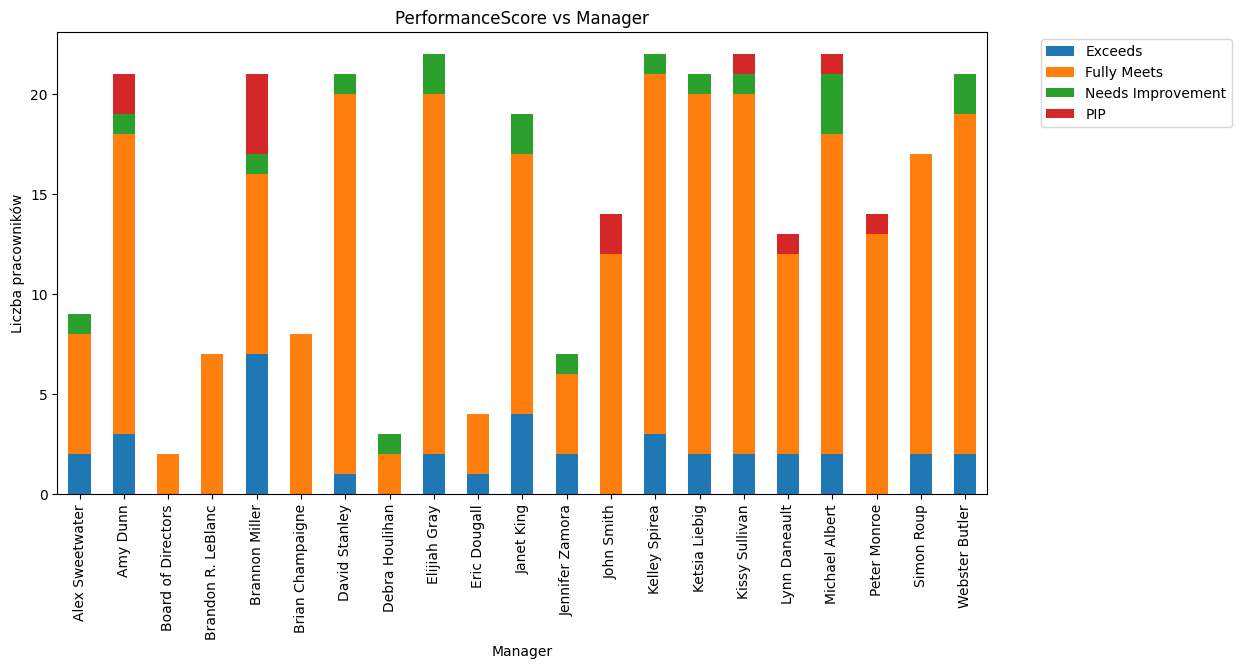

In [54]:
manager_performance.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title('PerformanceScore vs Manager')
plt.xlabel('Manager')
plt.ylabel('Liczba pracowników')

plt.legend(
    bbox_to_anchor=(1.05, 1),  # przesunięcie na prawo
    loc='upper left'            # kotwiczenie legendy
)

plt.show()

# Wnioski

Jak na moje to nie widze tu zadnej duzej zaleznosci

# 2 Jakie źródła pozyskania pracownika (Recruitment Source) są najlepsze, jeśli zależy nam na jak najdłuższym stażu pracowników?

In [55]:
df_small = df[['RecruitmentSource', 'Seniority']]   #tylko potrzebne kolumny

In [56]:
df_small

,RecruitmentSource,Seniority
0,Diversity Job Fair,10.923288
1,Website Banner Ads,5.726027
2,Internet Search,4.997260
3,Pay Per Click - Google,0.158904
4,Website Banner Ads,4.410959
...,...,...
396,NaN,NaN
397,NaN,NaN
398,NaN,NaN
399,NaN,NaN


In [57]:
df_small = df_small.dropna()  #usuniecie pustych danych

In [58]:
df_small

,RecruitmentSource,Seniority
0,Diversity Job Fair,10.923288
1,Website Banner Ads,5.726027
2,Internet Search,4.997260
3,Pay Per Click - Google,0.158904
4,Website Banner Ads,4.410959
...,...,...
305,Vendor Referral,4.882192
306,Employee Referral,4.882192
307,On-campus Recruiting,3.243836
308,Employee Referral,4.882192


In [59]:
df_small.groupby('RecruitmentSource')['Seniority'].mean().sort_values(ascending=False)   #sredni staz w zaleznosci od zrodla zatrutnienia (posortowane

RecruitmentSource
Careerbuilder                             8.487671
Other                                     6.457534
Billboard                                 5.866781
MBTA ads                                  5.733441
Website Banner Ads                        5.725395
Information Session                       5.627397
Professional Society                      5.441370
Employee Referral                         5.029342
Pay Per Click - Google                    5.012785
On-campus Recruiting                      5.009817
Monster.com                               4.838128
Internet Search                           4.714612
Newspager/Magazine                        4.596347
Diversity Job Fair                        4.495324
Search Engine - Google Bing Yahoo         4.363178
Glassdoor                                 4.157926
Vendor Referral                           4.146301
Word of Mouth                             3.649737
Social Networks - Facebook Twitter etc    3.466999
Indeed       

# prezentacja danych na wykresie

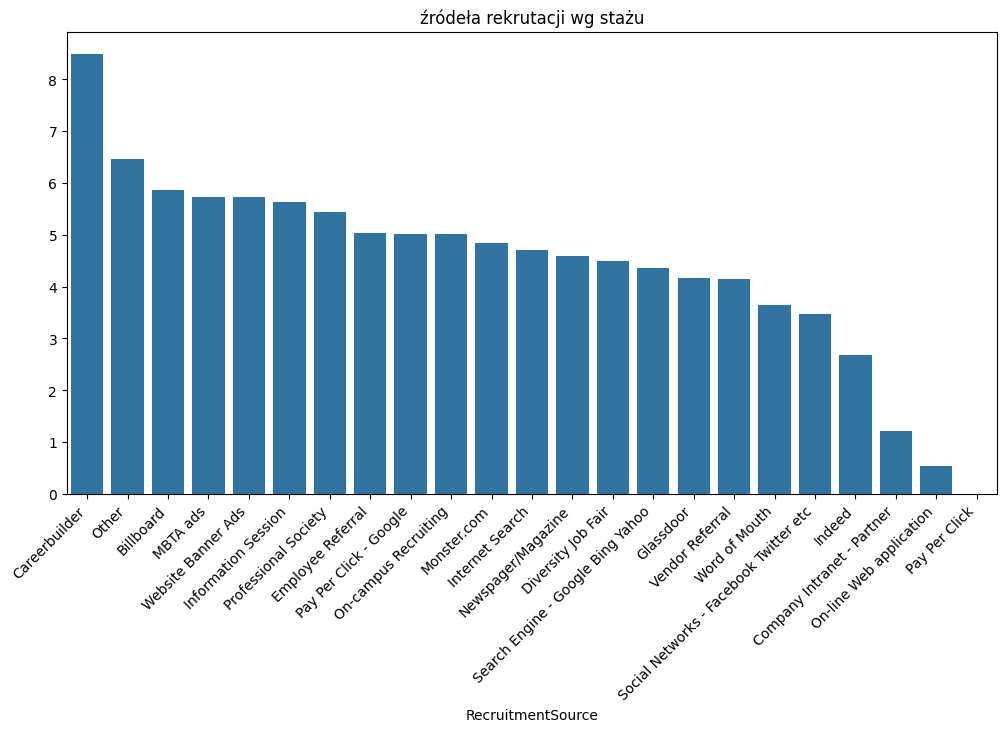

In [60]:
avg = df.groupby('RecruitmentSource')['Seniority'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))

sns.barplot(x=avg.index, y=avg.values)

plt.xticks(rotation=45, ha='right')

plt.title('źródeła rekrutacji wg stażu')
plt.show()

# WNIOSKI

Jesli zalezy nam na najdluzszym stazu to najlepszymi sposobami rekrutacji sa Careerbuilder or Other 

# 3 . Czy stan cywilny (MartialDesc) pracownika koreluje w jakikolwiek sposób z zadowoleniem z pracy (EmpSatisfaction)?

In [61]:
marital_satisfaction = (
    df.groupby('MaritalDesc')['EmpSatisfaction']
    .mean()
)

print(marital_satisfaction)

MaritalDesc
Divorced     4.033333
Married      3.747967
Separated    3.833333
Single       3.970803
Widowed      4.250000
Name: EmpSatisfaction, dtype: float64


# prezentacja na wykresie

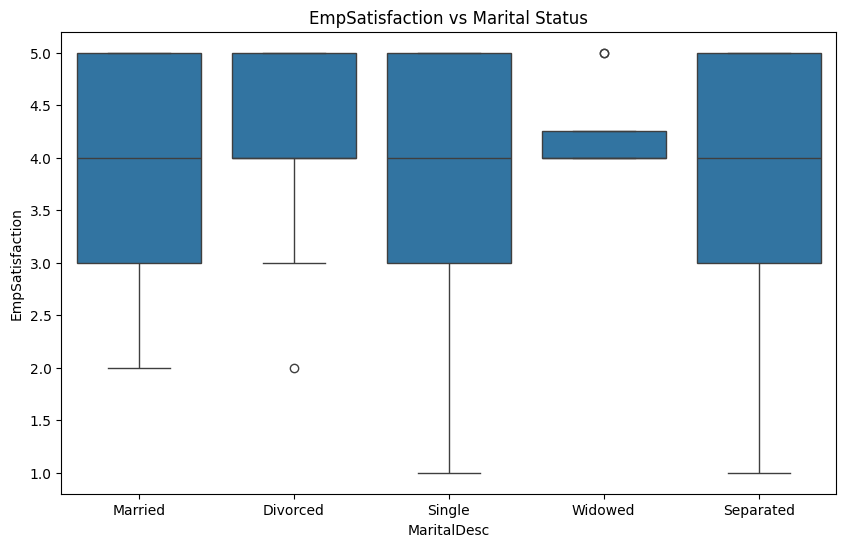

In [62]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='MaritalDesc',
    y='EmpSatisfaction',
    data=df
)

plt.title('EmpSatisfaction vs Marital Status')

plt.show()

# WNIOSKI

nie wiem jak przeanalizwac ten wykres zabardzo - wszystkie te grupy maja podobne zakresy. najbardziej skumulowane oceny maja 'owdowiali'

# 4.Struktura wieku aktywnych pracowników

In [68]:
df['DOB'] = pd.to_datetime(
    df['DOB'],
    format='%m/%d/%y'
)

In [71]:
df['DOB'].sort_values(ascending=False).head(20)

85    2075-12-17
15    2075-11-02
141   2075-10-22
84    2075-09-30
280   2075-09-16
20    2075-07-07
301   2075-05-05
222   2075-04-03
221   2075-03-10
206   2074-12-21
129   2074-12-05
273   2074-12-01
111   2074-11-07
183   2074-10-09
214   2074-08-09
151   2074-05-31
24    2074-05-09
94    2074-05-02
178   2074-02-21
118   2074-01-12
Name: DOB, dtype: datetime64[ns]

In [73]:
df['DOB'] = pd.to_datetime(df['DOB'], format='%m/%d/%y')

#cofamy błędnie sparsowane daty o 100 lat.
df.loc[df['DOB'].dt.year > 2025, 'DOB'] = (
    df.loc[df['DOB'].dt.year > 2025, 'DOB']
    - pd.DateOffset(years=100)
)

In [74]:
today = pd.to_datetime('today')

df['Age'] = (
    (today - df['DOB']).dt.days / 365
)

In [75]:
df['Age'].describe()

count    310.000000
mean      47.318948
std        8.893271
min       33.753425
25%       40.008904
50%       45.689041
75%       52.478082
max       75.405479
Name: Age, dtype: float64

In [76]:
active = df[df['EmploymentStatus'] == 'Active']

prezentajca na wykresie

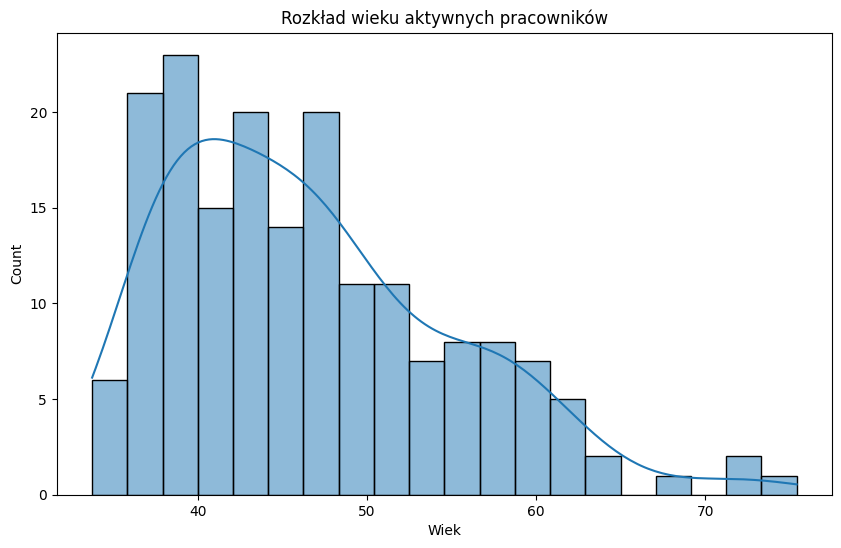

In [77]:
plt.figure(figsize=(10,6))

sns.histplot(
    active['Age'],
    bins=20,
    kde=True
)

plt.title('Rozkład wieku aktywnych pracowników')
plt.xlabel('Wiek')

plt.show()

# WNIOSKI

In [78]:
df['Age'].describe()

count    310.000000
mean      47.318948
std        8.893271
min       33.753425
25%       40.008904
50%       45.689041
75%       52.478082
max       75.405479
Name: Age, dtype: float64

Struktura wieku zatrudnionych przedstawia się następująco: 
- najstarszy pracownik ma 75 lat
- najmłodszy 33 lata
- a średnia wieku to 47 lat
- 

# 5 Czy starsi pracownicy mają więcej projektów?

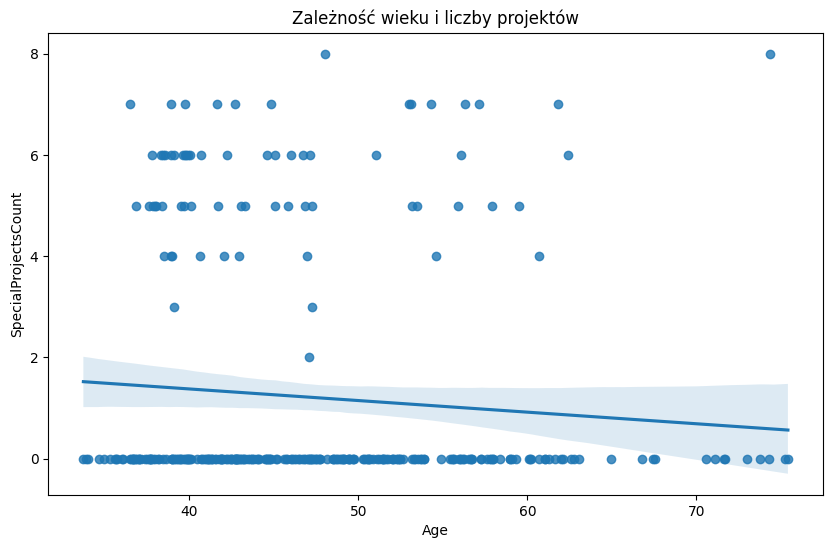

In [82]:
plt.figure(figsize=(10,6))

sns.regplot(
    x='Age',
    y='SpecialProjectsCount',
    data=df
)

plt.title('Zależność wieku i liczby projektów')

plt.show()

# wnioski

Starsi pracują nad mniejsza ilością projektów w porównaniu z młodszymi pracownikami ( i słusznie ;) )